In [84]:
#imports
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
# Perceptron de Rosenblatt
class Perceptron:
    def __init__(self, bias=1, step_param=0, learning_rate=0.1, 
                interval=(-0.5, 0.5), max_epochs=1000):
        self.b  = bias
        self.sp = step_param
        self.lr = learning_rate
        self.I = interval
        self.w  = None
        self.max_epochs=max_epochs
        self.epochs = 0
        self.total_adjustments = 0

    def _activation(self, x):
        activation = np.sum(xi * w for xi, w in zip(x, self.w))
        return (activation >= self.sp)

    def _learn(self, x, y, pred):
        e = y - pred
        dw = self.lr * e * np.array(x)
        self.w = self.w + dw
        self.total_adjustments += 1
        
    def fit(self, X, y, seed=None, shuffle=False):
        if seed is not None:
            np.random.seed(seed)
        # Adiciona o bias (1) a cada vetor de entrada
        X_bias = [x + [self.b] for x in X]
    
        # Inicializa os pesos com valores aleatórios
        if self.w is None:
            self.w = np.random.uniform(self.I[0], self.I[1], len(X_bias[0]))

        # Treinamento
        for _ in range(self.max_epochs):
            data = list(zip(X_bias, y))
            if shuffle:
                np.random.shuffle(data) # embaralha X e y juntos
            errors = 0
            for x, yi in zip(X_bias, y):
                pred = self._activation(x)
                if pred != yi:
                    self._learn(x, yi, pred)
                    errors += 1
            self.epochs += 1
            if errors == 0:
                break
            

        print(f"Total de {self.epochs} épocas")
        
    def predict(self, X):
        X_bias = [x + [self.b] for x in X]
        return [int(self._activation(x)) for x in X_bias]

In [86]:
p = Perceptron(bias=-1)
p.w = np.array([-0.5441, 0.5562, -0.4074]).transpose()
X = [[2, 2], [4, 4]]
y = [1, 0]
p.fit(X, y, seed=1)
print(p.w)
print(p.predict(X))

Total de 11 épocas
[-0.7441  0.3562 -0.8074]
[1, 0]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1296\3014542129.py:15: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  activation = np.sum(xi * w for xi, w in zip(x, self.w))


### Parte III - Validação _Houldout_ em Problema Não-Linearmente Separável

In [88]:
# Carregar dados
data_holdout = np.fromfile("./data/dataHoldout.txt", dtype=float).reshape(-1, 3)

In [91]:
# Preparar X e Y
X = data_holdout[:, :2]
y = data_holdout[:, 2].astype(int)

In [92]:
# Verificando as primeiras entradas 
print(X[:5])
print(y[:5])

[[-0.29322959 -0.09065359]
 [ 0.07988839  0.21101297]
 [-0.07825563 -0.08083512]
 [-0.46833414 -0.10620722]
 [ 0.46304142  0.09405471]]
[1 1 1 1 1]


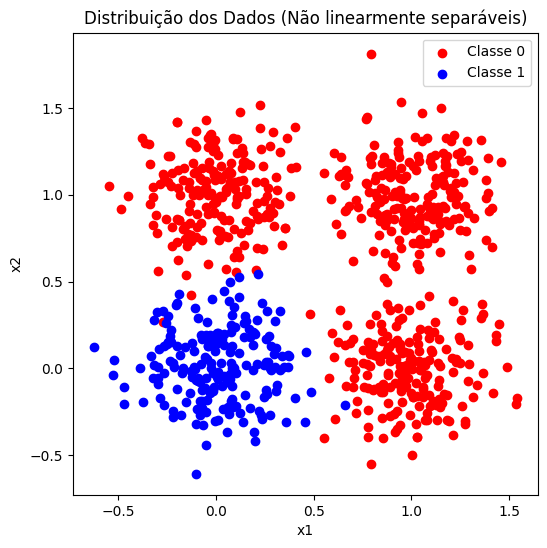

In [93]:
# Verificando a Não-Linearidade do Conjunto de Dados
x1 = X[:, 0]
x2 = X[:, 1]
# Classes em cores
colors = ['red' if label == 0 else 'blue' for label in y]

plt.figure(figsize=(6,6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', label='Classe 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Classe 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Distribuição dos Dados (Não linearmente separáveis)')
plt.show()

In [94]:
# Holdout split 70/30

# Aleatoriedade com base no identificador do grupo
identificador = 1
np.random.seed(identificador)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=identificador, shuffle=True
)


In [95]:
# Treinamento do Perceptron
p = Perceptron(max_epochs=100)
p.fit(X_train.tolist(), y_train.tolist(), shuffle=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1296\3014542129.py:15: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  activation = np.sum(xi * w for xi, w in zip(x, self.w))


Total de 100 épocas


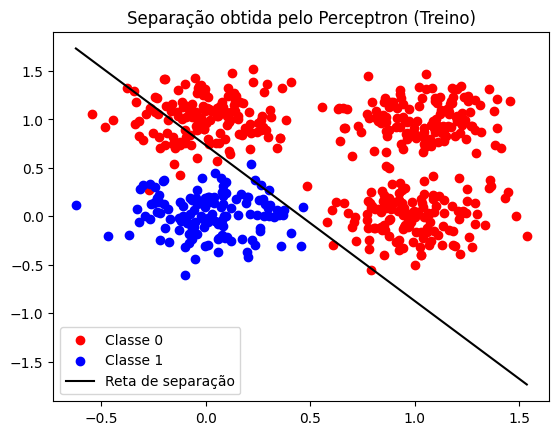

In [96]:
# Plotando reta de separação possível
w = p.w
x1 = np.linspace(min(X_train[:,0]), max(X_train[:,0]), 100)
x2 = -(w[0]*x1 + w[2]) / w[1] 

plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], color="red", label="Classe 0")
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], color="blue", label="Classe 1")
plt.plot(x1, x2, color="black", label="Reta de separação")
plt.legend()
plt.title("Separação obtida pelo Perceptron (Treino)")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1296\3014542129.py:15: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  activation = np.sum(xi * w for xi, w in zip(x, self.w))


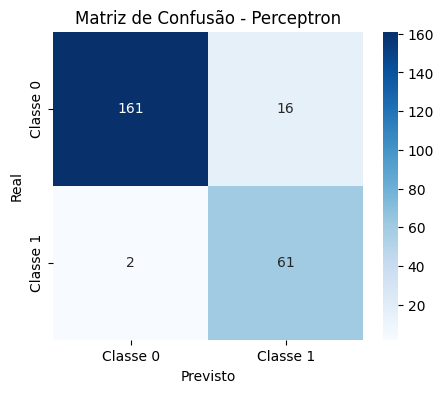

In [117]:
# Avaliando no conjunto de teste
y_pred = p.predict(X_test.tolist())

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Classe 0", "Classe 1"], 
            yticklabels=["Classe 0", "Classe 1"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Perceptron")
plt.show()

In [118]:
# Acurácia, Precisão, Revocação e F1-Score
correct = sum(1 for yi, yp in zip(y_test, y_pred) if yi == yp)
accuracy = correct / len(y_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Revocação: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Acurácia: 0.9250
Precisão: 0.7922
Revocação: 0.9683
F1-score: 0.8714


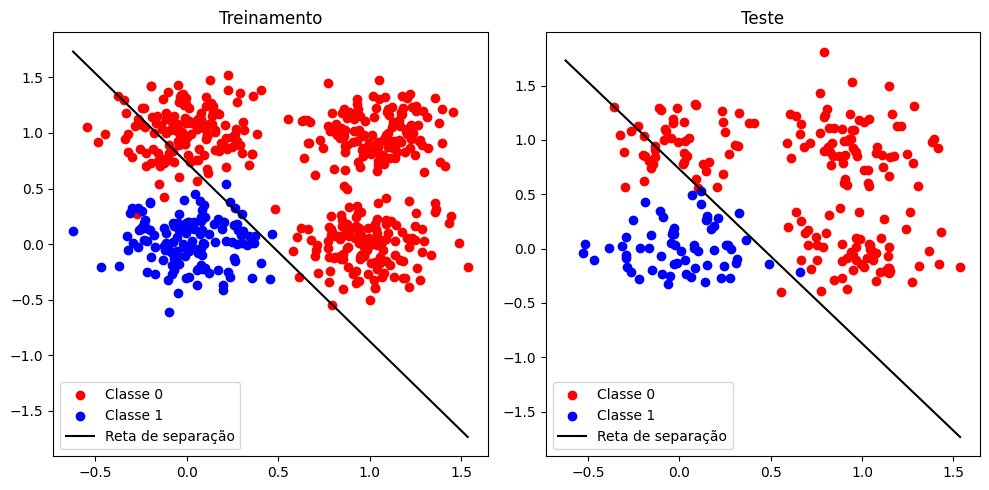

In [116]:
# Criar gráfico lado a lado
plt.figure(figsize=(10,5))

# Subplot 1 - Treinamento
plt.subplot(1,2,1)
plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], color="red", label="Classe 0")
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], color="blue", label="Classe 1")
plt.plot(x1, x2, color="black", label="Reta de separação")
plt.title("Treinamento")
plt.legend()

# Subplot 2 - Teste
plt.subplot(1,2,2)
plt.scatter(X_test[y_test==0,0], X_test[y_test==0,1], color="red", label="Classe 0")
plt.scatter(X_test[y_test==1,0], X_test[y_test==1,1], color="blue", label="Classe 1")
plt.plot(x1, x2, color="black", label="Reta de separação")
plt.title("Teste")
plt.legend()

# Ajusta layout e mostra tudo junto
plt.tight_layout()
plt.show()


Conclusões

Embora o problema seja não linearmente separável, os resultados do Perceptron foram satisfatórios. A acurácia obtida no conjunto de testes foi de 92,5%, com precisão de 79,22%, revocação de 96,83% e F1-score de 87,14%. Esses valores indicam que o modelo foi capaz de capturar bem o padrão presente nos dados, ainda que apresente algumas falhas na identificação de exemplos positivos (precisão mais baixa).
Em resumo, mesmo limitado por sua natureza linear, o Perceptron conseguiu oferecer uma separação consistente, confirmando sua utilidade em problemas simples, embora não seja a solução ideal para dados que não são linearmente separáveis.

Sobre a linha de decisão obtida pelo Perceptron, observa-se que a mesma não se ajusta perfeitamente à distribuição dos dados, já que o problema não é linearmente separável, conforme o esperado. Ainda assim, a solução encontrada pelo modelo apresenta boas métricas de desempenho, como acurácia superior a 90%. Isso confirma que, mesmo não representando perfeitamente os limites entre as classes, o Perceptron foi capaz de capturar um padrão útil nos dados.